In [6]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
%matplotlib inline

In [7]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [9]:
X,Y = [], []
block_size = 3
for w in words:
    context = [0] * block_size
    #print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context) , '--->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [10]:
# INITIALISATION BLOCK
C = torch.randn((27,2))
W1 = torch.randn((6,100))
B1 = torch.randn((100))
W2 = torch.randn((100,27))
B2 = torch.randn((27))
parameters = [C , W1, B1, W2, B2]
for p in parameters:
    p.requires_grad = True

In [11]:
# HOW TO DETERMINE A GOOD LEARNING RATE:
x = torch.linspace(0.001 , 1 , 1000)
lre = torch.linspace(-3, 0 , 1000) # WE USE THIS TO STEP EXPONENTIALLY INSTEAD OF LINEARLY
lrs = 10 ** lre
lri , lossi = [] , []

In [12]:
for i in range(1000):
    #---MINIBATCHING---
    ix = torch.randint(0, X.shape[0], (32,))
    #---FORWARD PASS---
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,Y[ix])
    #print(loss.item())

    #---BACKWARD PASS---
    for p in parameters:
        p.grad = None
    loss.backward()

    #---UPDATING---
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

     #---TRACKING STATS--- 
    lri.append(lre[i])
    lossi.append(loss.item())

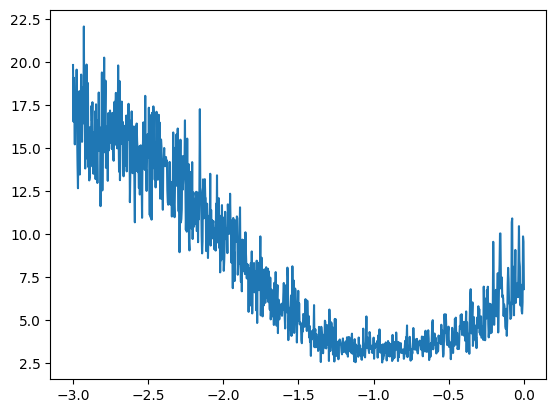

In [13]:
plt.plot(lri ,lossi) #THIS SHOWS THAT A GOOD LEARNING RATE IS AROUND -1